<!-- <img src="../code/Resources/cropped-SummerWorkshop_Header.png">  -->

<h1 align="center">Workshop 1: Tutorial on behavioral states </h1> 
<h3 align="center">Summer Workshop on the Dynamic Brain</h3> 
<h3 align="center">Thursday, August 24th, 2026</h3> 
<h4 align="center">Day 2</h4> 

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> During the lecture, we learned about behavioral states and how they affect the processing of sensory stimuli and, consequently, motor outputs. In this workshop, we will explore how to define behavioral states and investigate both external and internal markers of state changes reflected through behavior as well as neural activity. We will examine these phenomena in mice as they perform a context-dependent decision-making task.

<p> During the task, the mice are engaged in behavior that requires them to process contextual cues, interact with their environment, and display a variety of behavioral state sequences. Meanwhile, Neuropixels electrodes record brain-wide spiking activity across the cortex and several hippocampal, striatal and thalamic areas. The behavioral task, therefore, offers an opportunity to study the dynamics of spiking activity during various behavioral states and aids in understanding the behavioral dynamics of task performance and engagement.     
</div>

<center><img src="/root/capsule/code/resources/DR_task_description.png" style="width:1800px; height:600px; max-width:none;"> </center>

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> The Dynamic Routing (DR) dataset (refer to <a href="https://allenswdb.github.io/physiology/ephys/visual-behavior/VB-Neuropixels.html">DR Databook</a>) consists of brain-wide recordings of neural activity measured using six Neuropixels probes from twelve mice trained to perform a context-dependent decision-making task. Throughout the session, behavior video cameras and running sensors continuously track various body parts, running speed, and pupil size of the subjects.

<p> In this go/no-go task, mice are required to selectively respond to either visual or auditory stimuli presented in alternating trial blocks. Each block, signaled by instruction trials, lasts 10 minutes. During visual blocks, mice must respond only to the visual target stimulus (VIS+), while during auditory blocks, they must respond only to the auditory target stimulus (AUD+). In both blocks, they must suppress responses to non-target stimuli (AUD-, VIS-). The blocks alternate between visual and auditory modalities for a total of six blocks, and mice earn water rewards by correctly reporting (licking the water spout) when the target stimulus appears in the currently rewarded modality.  
</div>

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">

The DR dataset is stored as Neurodata Without Borders (NWB) files, a standardized format for storing neurophysiology data. To access these files, we will use the Python library <a href="https://pynwb.readthedocs.io/en/stable/tutorials/index.html">pynwb</a>, which is designed for reading and writing NWB data. We begin by importing this library along with other standard Python libraries for data preprocessing and plotting.

</div>

In [1]:
# Standard library
import os  
from pathlib import Path  # Object-oriented filesystem paths

# Data handling packages
import numpy as np  
import numpy.random as npr  
import pandas as pd 
import pynwb  


# Progress bar utility
from tqdm import tqdm  # Displays a smart progress bar during loops

# Preprocessing
from sklearn.preprocessing import StandardScaler  # Standardizes features (zero mean, unit variance)

# Plotting libraries
import matplotlib.pyplot as plt  
from matplotlib import colors  
import seaborn as sns  

# Pandas display settings
pd.set_option('display.max_columns', None)  # Ensures all columns are shown when printing DataFrames

# Inline plotting for Jupyter Notebooks
%matplotlib inline  


##  Load the Dynamic Routing experiment from NWB

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
Let’s examine the NWB file structure of a single experimental session and explore the metadata recorded for each behavioral trial. All experimental sessions share the same NWB structure.
</div>

In [2]:
example_session_ids = [
                        "668755_2023-08-31",  "759434_2025-02-04", "713655_2024-08-09", 
                        "743199_2024-12-05", "667252_2023-09-26", "712815_2024-05-22", 
                        "702131_2024-02-26", "742903_2024-10-23", "664851_2023-11-16", 
                        "741137_2024-10-10", "674562_2023-10-03", "644864_2023-02-02"
                    ]


session_id = example_session_ids[0]
root = Path("/root/capsule/data/dynamicrouting_datacube_v0.0.272")

# loop through the directories to find the NWB file for the specific session 
for d in root.iterdir():
    nwb_path = d / f"{session_id}.nwb"
    if nwb_path.exists():
        print(nwb_path)
        break

/root/capsule/data/dynamicrouting_datacube_v0.0.272/nwb/668755_2023-08-31.nwb


In [3]:
# access the session data with pynwb - should take about a minute
session = pynwb.NWBHDF5IO(nwb_path).read()

# Quick reference of the NWB file structure
# Important groups include: units, trials, intervals, and processing 
session

Data type,float64
Shape,"(417595,)"
Array size,3.19 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),3340760
Compressed size (bytes),3340760
Compression ratio,1.0
Data type,float64
Shape,"(417601,)"


In [4]:
# Get trials dataframe and look at a few rows
trials = session.trials[:]
trials.tail(7)

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,reward_time,post_response_window_start_time,post_response_window_stop_time,stim_name,block_index,rewarded_modality,trial_index,trial_index_in_block,repeat_index,is_response,is_correct,is_incorrect,is_hit,is_false_alarm,is_correct_reject,is_miss,is_go,is_nogo,is_rewarded,is_noncontingent_reward,is_contingent_reward,is_reward_scheduled,is_instruction,is_aud_stim,is_vis_stim,is_catch,is_target,is_aud_target,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
517,6055.91184,6061.46651,6055.91184,6057.39631,6057.43761,6057.93761,6057.51308,6058.43051,NaN,NaN,NaN,6058.45798,6061.493870,sound2,5,aud,517,83.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,True,False,False,False,False
518,6061.49978,6067.03783,6061.49978,6062.96769,6063.02849,6063.54561,6063.08436,6064.01882,NaN,NaN,NaN,6064.04603,6067.065200,vis2,5,aud,518,84.0,0.0,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,True,False,False,False,False
519,6067.12114,6072.65912,6067.12114,6068.58907,6068.63048,6069.13048,6068.70581,6069.62323,6069.53996,6069.53459,NaN,6069.65073,6072.686620,sound2,5,aud,519,85.0,0.0,True,False,True,False,True,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,True,False,False,False,False
520,6072.75917,6078.29728,6072.75917,6074.22704,6074.28795,6074.80503,6074.34393,6075.27797,6074.67753,6074.67754,NaN,6075.30545,6078.324660,vis1,5,aud,520,86.0,0.0,True,False,True,False,True,False,False,False,True,False,False,False,False,False,False,True,False,True,False,True,False,False,False,False,True,False,False,False,False
521,6078.56407,6084.10208,6078.56407,6080.03204,6080.07297,6080.57297,6080.14884,6081.06613,6080.29887,6080.29881,6080.31550,6081.09363,6084.129510,sound1,5,aud,521,87.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
522,6084.61915,6090.15718,6084.61915,6086.08703,6086.12837,6086.62837,6086.20377,6087.13802,6086.35396,6086.35296,6086.37074,6087.16541,6090.184580,sound1,5,aud,522,88.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False
523,6090.29055,6095.82857,6090.29055,6091.75849,6091.79956,6092.29956,6091.87533,6092.79273,6092.02534,6092.01987,6092.04204,6092.82015,6095.856025,sound1,5,aud,523,89.0,0.0,True,True,False,True,False,False,False,True,False,True,False,True,False,False,True,False,False,True,True,False,False,False,False,False,True,False,False,False,False


<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
How well does the mouse modulate its responses to target stimuli based on the context block? We address this by quantifying its response rate for each target stimulus.
</div>

## Mouse behavioral performance over the session

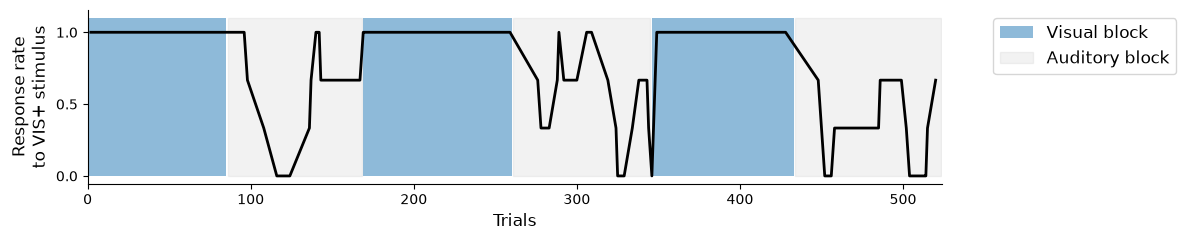

In [26]:
# response rates to target 
vis_target_response_rate =  trials[trials.is_vis_target].is_response.rolling(3).mean()

fig, ax = plt.subplots(figsize = (12, 2.5), sharex = True, sharey = True)
ax.plot(vis_target_response_rate, color = 'k',  lw = 2)

# add block information 
vis_block = trials.is_vis_rewarded
ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')
    

# formatting

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks([0, 0.5, 1])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)

ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response rate\nto VIS+ stimulus', fontsize = 12)
plt.tight_layout()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<p><b>Task 1.1:</b> Re-write the code below to evaluate hit rates calculated on the auditory target stimulus.
</p> </div>

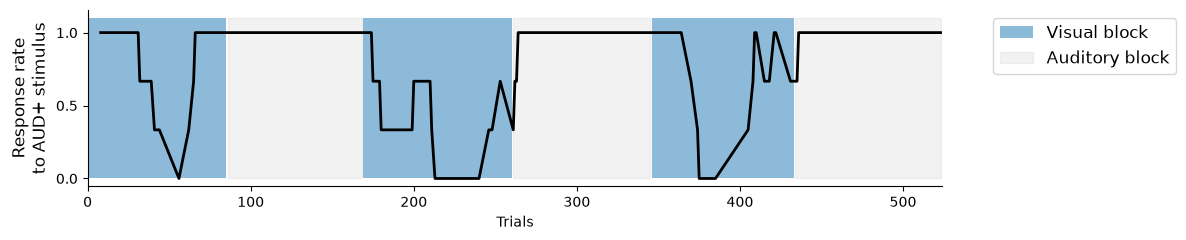

In [29]:
# Blank coding cell to work out Task 1.1  

# response rates to target 
aud_target_response_rate =  trials[trials.is_aud_target].is_response.rolling(3).mean()

fig, ax = plt.subplots(figsize = (12, 2.5), sharex = True, sharey = True)
ax.plot(aud_target_response_rate, color = 'k',  lw = 2)

# add block information 
vis_block = trials.is_vis_rewarded
ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
ax.fill_between(vis_block.index, 0, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')
    

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks([0, 0.5, 1])
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)

ax.set_xlabel('Trials')
ax.set_ylabel('Response rate\nto AUD+ stimulus', fontsize = 12)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF;">

Visual and auditory hit rates provide separate measures of performance in each context. The **response modulation index (RMI)** combines these measurements into a single metric, allowing us to quantify the mouse's context-dependent response strategy.

$$
\mathrm{RMI} =
\frac{R_{\mathrm{vis}} - R_{\mathrm{aud}}}
{R_{\mathrm{vis}} + R_{\mathrm{aud}}}
$$

where $R_{\mathrm{vis}}$ and $R_{\mathrm{aud}}$ are the rolling response rates for visual and auditory target stimuli, respectively.

</div>

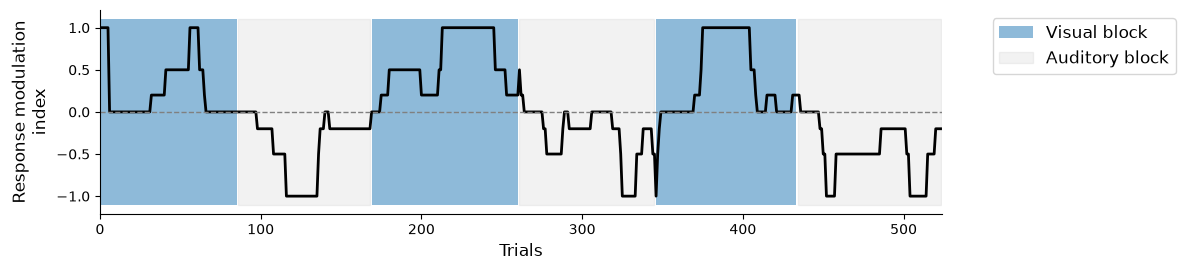

In [6]:
# response modulation index 

# Select target trials and sort by index for consistency
subset_trials = (
    trials.loc[trials.is_vis_target | trials.is_aud_target]
    .sort_index()
    .copy()
)

window = 3  # Define the rolling window size

# Response rate across the most recent visual target trials
vis_target_response_rate = (
    subset_trials[subset_trials.is_vis_target].is_response
    .astype(float)
    .rolling(window=window, min_periods=1)
    .mean()
)

# Response rate across the most recent auditory target trials
aud_target_response_rate = (
    subset_trials[subset_trials.is_aud_target].is_response
    .astype(float)
    .rolling(window=window, min_periods=1)
    .mean()
)

# Place rate estimates back onto the full target-trial sequence, Fill NaN values by propagating
trials["vis_target_response_rate"] = vis_target_response_rate.reindex(trials.index).ffill().fillna(0)
trials["aud_target_response_rate"] = aud_target_response_rate.reindex(trials.index).ffill().fillna(0)


# Response Modualtion index = (vis_target_response_rate - aud_target_response_rate) / (vis_target_response_rate + aud_target_response_rate)
# calculate denominator for response modulation index
denominator = (
    trials["vis_target_response_rate"]
    + trials["aud_target_response_rate"]
)

trials["response_modulation_index"] = np.where(
    denominator > 0,
    (
        trials["vis_target_response_rate"]
        - trials["aud_target_response_rate"]
    ) / denominator,
    np.nan,
)

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot(trials["response_modulation_index"], color="k", lw=2)
ax.plot([0, len(trials)], [0, 0], color="gray", lw=1, ls="--")

# add block information 
vis_block = trials.is_vis_rewarded
ax.fill_between(vis_block.index, -1.1, 1.1, where=vis_block == 1, alpha=0.5, label = 'Visual block')
ax.fill_between(vis_block.index, -1.1, 1.1, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')

# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_xlabel("Trials", fontsize = 12)
ax.set_ylabel("Response modulation\nindex", fontsize = 12)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize = 12)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
The mouse modulates its responses according to the current context block, indicating that it transitions between distinct behavioral states. 
</div>

## Identifying behavioral states based on visual inspection

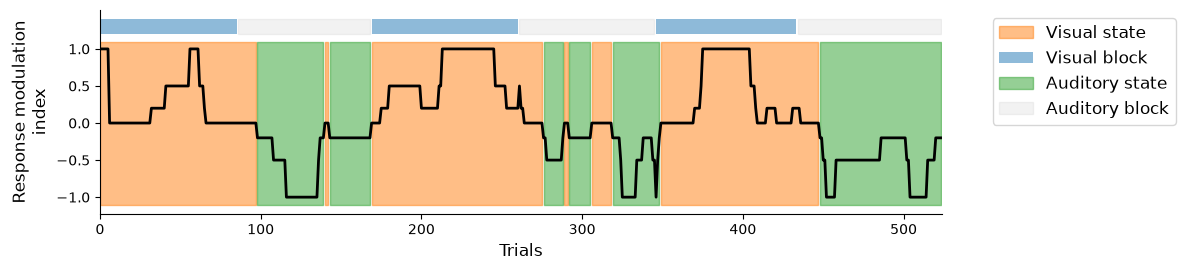

In [7]:
# response rate thresholds for each modality
response_threshold = 0
behavioral_state = trials["response_modulation_index"] >= response_threshold

fig, ax = plt.subplots(figsize = (12, 2.8))
ax.plot( trials["response_modulation_index"], color = 'k',  lw = 2)

ax.fill_between(behavioral_state.index, -1.1, 1.1, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 1, alpha=0.5, label = 'Visual block')

ax.fill_between(behavioral_state.index, -1.1, 1.1, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
ax.fill_between(vis_block.index, 1.2, 1.4, where=vis_block == 0, alpha=0.2, label = 'Auditory block', color = 'silver')


# formatting
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(0, len(trials))
ax.set_yticks(np.arange(-1, 1.1, 0.5))
ax.set_xlabel('Trials', fontsize = 12)
ax.set_ylabel('Response modulation\nindex', fontsize = 12) 
ax.legend(bbox_to_anchor=(1.05, 1), fontsize = 12)
plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
When the mouse’s state changes, does it affect other aspects of its behavior too? To answer this, let’s look beyond their task performance and examine additional variables including running speed and pupil position.
</div>

## Do spontaneous behaviors reflect behavioral state?

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
To avoid motor confounds during reward consumption, let’s focus our analysis on the quiescent period.
</div>

In [8]:
def get_trialwise_values(x, timestamps, start, stop):
    """
    Extracts trial-wise summary statistics of different behaviors (mean or median) from a time-aligned signal.

    Parameters:
    - x : array-like
        Signal values (e.g., neural data or behavioral measurements).
    - timestamps : array-like
        Time points corresponding to each value in x.
    - start : array-like
        Start times for each trial.
    - stop : array-like
        Stop times for each trial.

    Returns:
    - values : list
        List of mean or median values for each trial window.
    """
    return np.array([np.nanmean(x[np.logical_and(s1 <= timestamps, timestamps <= s2)]) 
            for s1, s2 in zip(start, stop)])

def get_facial_feature(part_name, facial_features_df):
    """
    Extracts and preprocesses the Y-coordinate of a facial feature from a dataframe.

    Parameters:
    ----------
    part_name : str
        The name of the facial feature/part.
    facial_features_df : pandas.DataFrame

    Returns:
    -------
    y : np.ndarray
        Cleaned and interpolated Y-coordinate time series of the feature.
    """

    # Extract likelihood (confidence of detection) for the feature
    confidence = facial_features_df[f'{part_name}_likelihood']

    # Extract temporal norm
    temporal_norm = facial_features_df[f'{part_name}_temporal_norm']

    # Flip Y-coordinate relative to image height
    y = 492 - facial_features_df[f'{part_name}_y']

    # Mask low-confidence or high-temporal-norm points as NaN (to discard unreliable or jumpy detections)
    y[(confidence < 0.99) | 
      (temporal_norm > np.nanmean(temporal_norm) +  2*np.nanstd(temporal_norm))] = np.nan

    # center and remove outliers
    y_centered = y - np.nanmean(y)
    y_abs_centered = np.abs(y_centered)
    y_centered[y_abs_centered > np.nanmean(y_abs_centered) + 2*np.std(y_abs_centered) ]  = np.nan

    # Interpolate missing values (NaNs) to create a continuous time series
    y_interp = pd.Series(y_centered).ffill().bfill().to_numpy()

    return y_interp

In [9]:
# access trials table and get the start and stop times
trial_start = trials.stim_start_time.values - 1.5 
trial_stop = trials.stim_start_time.values 

behavior_data = {}

# facial expressions: 
facial_features_df = session.processing['behavior']['lp_side_camera'][:]
feature_timestamps = facial_features_df['timestamps'].values.astype('float')


ear = get_facial_feature('ear_base_l', facial_features_df)
behavior_data['ear'] = get_trialwise_values(ear, feature_timestamps, trial_start, trial_stop)

nose = get_facial_feature('nose_tip', facial_features_df)
behavior_data['nose'] = get_trialwise_values(nose, feature_timestamps, trial_start, trial_stop)

jaw = get_facial_feature('jaw', facial_features_df)
behavior_data['jaw'] = get_trialwise_values(jaw, feature_timestamps, trial_start, trial_stop)

whisker_pad = get_facial_feature('whisker_pad_l_side', facial_features_df)
behavior_data['whiskers'] = get_trialwise_values(whisker_pad, feature_timestamps, trial_start, trial_stop)

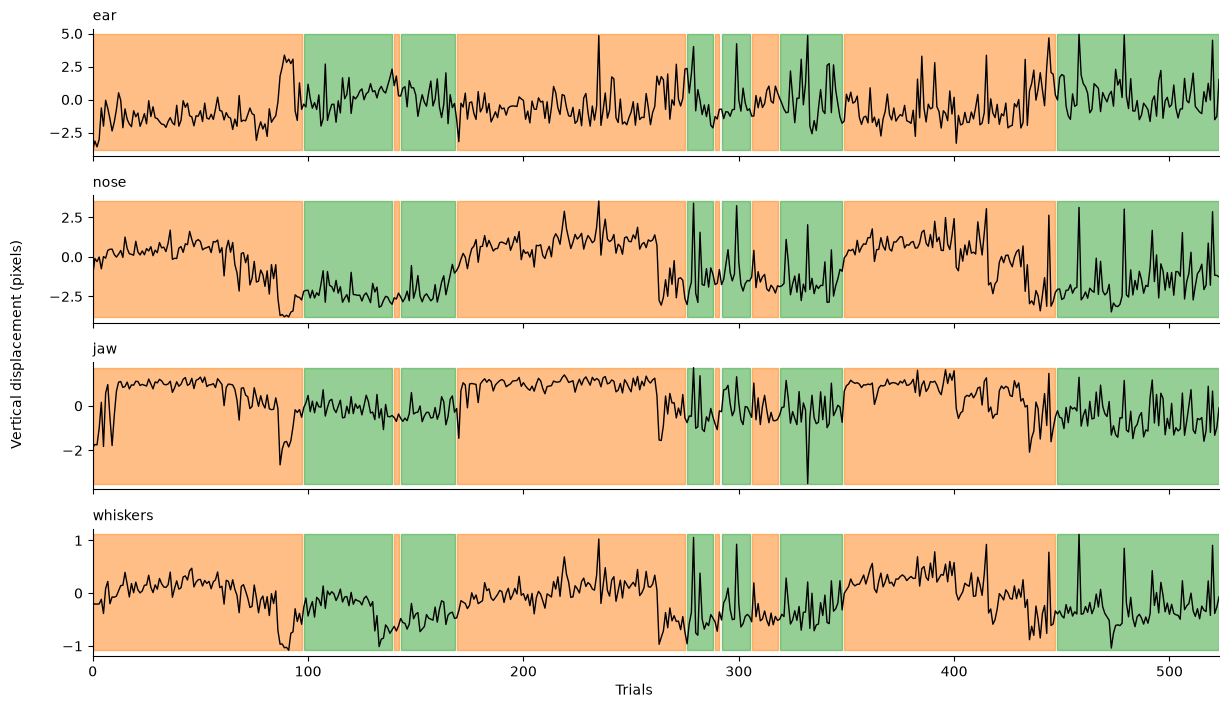

In [10]:
keys_to_plot = ['ear', 'nose', 'jaw', 'whiskers']

fig, ax = plt.subplots(4, 1, figsize = (12, 7), sharex = True)


for i, key in enumerate(keys_to_plot):
    ax[i].plot(trials.index, behavior_data[key], color = 'k', lw = 1)
    ax[i].set_title(key, fontsize = 10, loc = 'left')
    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].set_xlim(trials.index[0], trials.index[-1])

    
    # Get min and max of this behavior trace
    min_val = np.nanmin(behavior_data[key])
    max_val = np.nanmax(behavior_data[key])

    # add state information 
    
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')

fig.text(0.5, 0.00, 'Trials', ha='center')
fig.text(-0.02, 0.5, 'Vertical displacement (pixels)', va='center', rotation='vertical')
plt.tight_layout()

In [ ]:
# running speed
running_data = session.processing['behavior']['running_speed']
running_timestamps = running_data.timestamps[:]
running_speed = running_data.data[:]
running_speed = pd.Series(running_speed).interpolate(limit_direction='both').to_numpy() 
behavior_data['running_speed'] = get_trialwise_values(running_speed, running_timestamps, trial_start, trial_stop)

# pupil area
pupil_data = session.processing['behavior']['eye_tracking']
pupil_timestamps = pupil_data.timestamps[:]
pupil_area = pupil_data.pupil_area[:]
pupil_area = pd.Series(pupil_area).interpolate(limit_direction='both').to_numpy() 
behavior_data['pupil_area'] = get_trialwise_values(pupil_area, pupil_timestamps, trial_start, trial_stop)

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
<p><b>Task 1.2:</b> How do running speed and pupil size vary across behavioral states? Can you plot it
</p> </div>

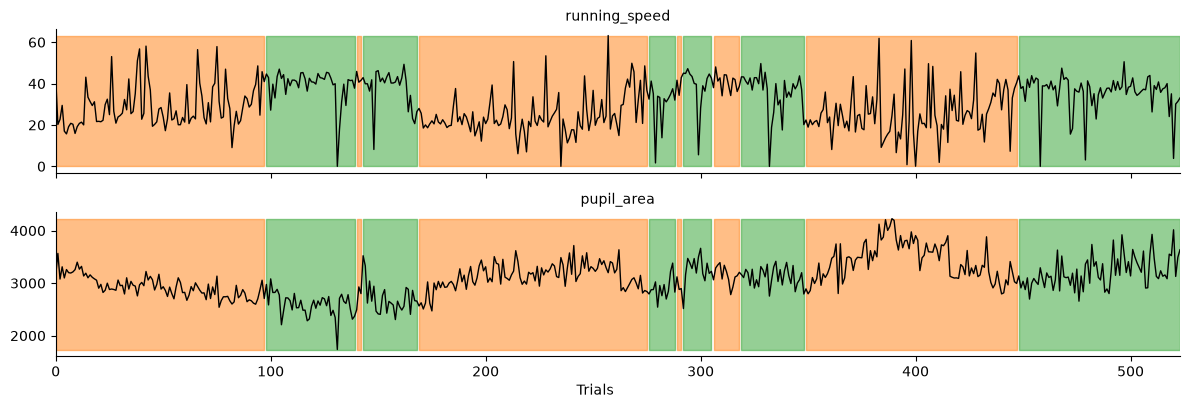

In [11]:
# Blank coding cell to work out Task 1.2
keys_to_plot = ['running_speed', 'pupil_area']

fig, ax = plt.subplots(2, 1, figsize = (12, 4), sharex = True)

for i, key in enumerate(keys_to_plot):
    ax[i].plot(trials.index, behavior_data[key], color = 'k', lw = 1)
    ax[i].set_title(key, fontsize = 10)
    
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    ax[i].set_xlim(trials.index[0], trials.index[-1])

    # Get min and max of this behavior trace
    min_val = np.nanmin(behavior_data[key])
    max_val = np.nanmax(behavior_data[key])
    
    # add block information 
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 0, alpha=0.5, color = 'tab:green', label = 'Auditory state')
    ax[i].fill_between(behavioral_state.index,  min_val, max_val, where=behavioral_state == 1, alpha=0.5, color = 'tab:orange', label = 'Visual state')


fig.text(0.5, 0.00, 'Trials', ha='center')

plt.tight_layout()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> So, while defining behavioral states by thresholding the response modulation rate is a useful starting point, it is incomplete. There are several additional variables that could provide more nuanced insights into the mouse’s behavioral states but we have not incorporated these into our definition of behavioral states. </p>

<p> Moreover, the threshold we used to define behavioral states appeared appropriate for the mouse we studied but may not generalize across animals. How, then, can we systematically assess state changes across many mice? </p>

<p> In the remainder of this workshop, we will explore more sophisticated methods for defining behavioral states that integrate multiple features to provide a richer, more reliable description of each mouse’s behavioral profile. </p>

</div>

## Examine covariation between behavioral features

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
First, we'll learn how to make sense of a more complex view of the behavioral information. Instead of looking at just one behavioral variable, we will examine multiple variables simultaneously to gain a better understanding of what's going on. As we have seen, some of these behavior variables correlate with the task-engaged behavioral state and also correlate with each other. Let's create a visualization to see how the different behavioral variables are correlated.

</div>


In [12]:
# Convert behavior_data dictionary to dataframe for ease of use 
behavior_df = pd.DataFrame(behavior_data)
behavior_df.head(7)

,ear,nose,jaw,whiskers,running_speed,pupil_area
0,-3.841754,-1.147337,-1.872295,-0.185089,42.650874,3146.053606
1,-3.146363,-0.100944,-1.740711,-0.208340,20.249099,3565.488507
2,-3.583573,-0.297655,-1.751240,-0.206322,22.703644,3077.334327
3,-3.011291,-0.008680,-1.005204,-0.204938,29.461109,3310.618467
4,-0.636616,-0.752833,0.158535,-0.115319,17.022648,3098.773178
5,-2.015699,0.021840,-1.826702,-0.385057,15.684530,3257.878839
6,-0.053364,-0.079705,0.569487,0.089535,19.165764,3198.644163


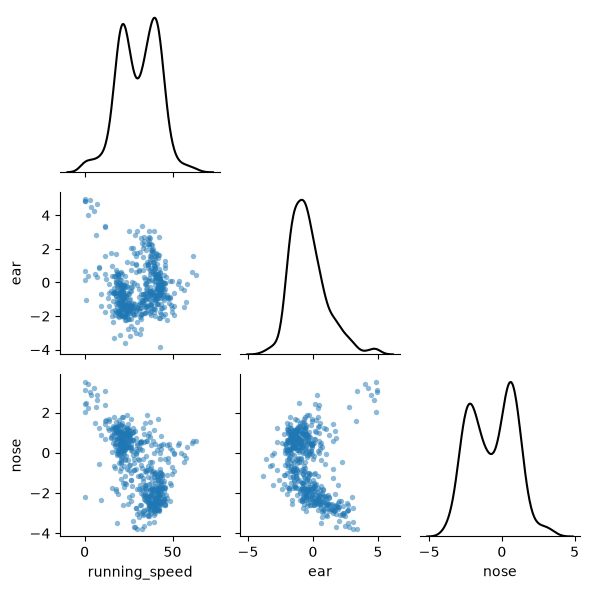

In [13]:
# Variables to include in the pairwise plot
variables = ["running_speed", "ear", "nose"]

# Initialize the PairGrid with only the lower triangle
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots in the lower triangle
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.5,
    linewidth=0,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method="scott",
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()
plt.show()

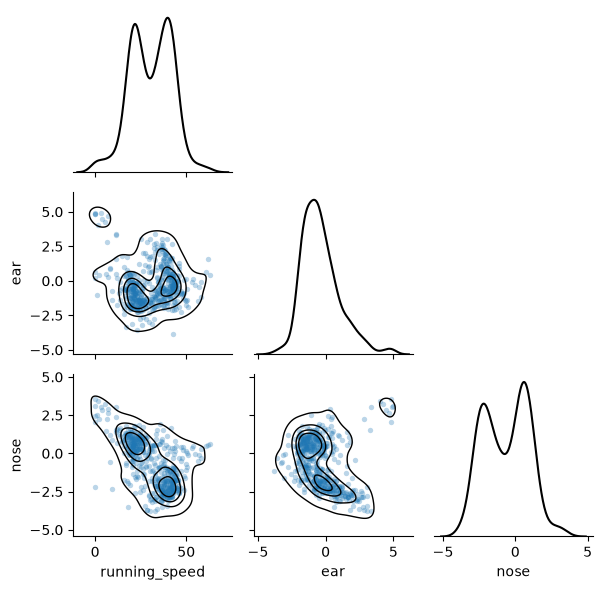

In [14]:
# Variables to include in the pairwise plot


# Bandwidth method for KDE
width = "scott"

# Initialize the PairGrid with only the lower triangle
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots in the lower triangle
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.3,
    linewidth=0,
)

# Overlay 2D kernel density contours
g.map_lower(
    sns.kdeplot,
    bw_method=width,
    levels=5,      # Number of contour levels
    color="k",     # Black contour lines
    linewidths=1,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method=width,
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()

plt.show()

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"> 
Task 1.3: In the pairwise density plots, try playing around with the option 'bw_method' by setting it to scalar values between [0.2, 1]. How does this affect the density plots? Do you still think there are only 2 states? Do this below. 
</div>

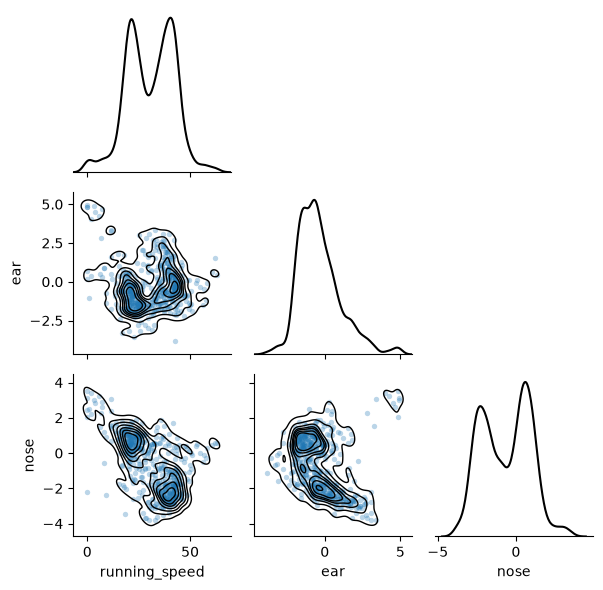

In [15]:
# Blank coding cell to work out Task 1.3
# Variables to include in the pairwise plot
variables = ["running_speed", "ear", "nose"]

# Bandwidth method for KDE
width = 0.2

# Initialize the PairGrid with only the lower triangle
g = sns.PairGrid(
    behavior_df,
    vars=variables,
    corner=True,
    diag_sharey=False,
)

# Plot scatterplots in the lower triangle
g.map_lower(
    sns.scatterplot,
    s=15,
    alpha=0.3,
    linewidth=0,
)

# Overlay 2D kernel density contours
g.map_lower(
    sns.kdeplot,
    bw_method=width,
    levels=8,      # Number of contour levels
    color="k",     # Black contour lines
    linewidths=1,
)

# Plot 1D kernel density estimates along the diagonal
g.map_diag(
    sns.kdeplot,
    bw_method=width,
    legend=False,
    color = 'k'
)

# Formatting
g.figure.set_size_inches(6, 6)
g.figure.tight_layout()

plt.show()

<div style="border-left: 3px solid #000; border-radius: 3px; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
This visualization broadly showed two states that mapped well to our previous state definitions. But playing around with the density plots may have raised some doubts that there were only two states.

Does every peak deserve a behavior state? How can we define state boundaries while incorporating all behavior variables? Are there other behavior states?

Moreover, when determining behavioral states, we are dealing with data that changes over time, where the current state may depend on the current observation and also on the previous state. How do we incorporate time information?!
</div>

## !! Whiteboard session !! 

<div style="border-left: 3px solid #000; border-radius: 3px;  padding: 1px; padding-left: 10px; background: #F0FAFF; ">
<h4>Multivariate definition of behavioral states</h4>

<p>The density plots suggest there may be multiple underlying behavioral states. One approach to identifying these states is to use unsupervised clustering methods to group similar observations across multiple behavioral variables, revealing distinct patterns that may correspond to different states.</p>

<p>K-means and Gaussian Mixture Models (GMMs) are two such clustering methods. While K-means assigns each data point to a single cluster with a deterministic assignment, GMMs allow data points to belong to multiple clusters with varying degrees of membership probabilities, making them more flexible than K-means. Unlike K-means, GMMs can model clusters with different shapes and orientations, providing a more realistic representation of the underlying structure.</p>

<p>Let’s see how we can draw a link from K-means clustering to GMMs. By making this connection, we will introduce a new tool to your toolbox: the concept of a mixture model, which seeks to maximize the likelihood of the observed data under a combination of probability distributions.</p>
</div>

<style>
.jp-RenderedMarkdown blockquote {
  border-left: 3px solid #000;
  border-radius: 3px;
  padding: 8px 12px;
  background: #F0FAFF;
  margin: 0.5em 0;
}
.jp-RenderedMarkdown blockquote p {
  margin: 0.5em 0;
}
</style>

> ### K-means and Gaussian Mixture Models
>
> First, lets sort out our notation:
>
> **Constants**
>
> - N - number of data points.
> - K - number of clusters/components.
>
> **Data**
>
> - $\mathbf{X} = \{x_n\}_{n=1}^{N}$ where $x_n \in \mathbb{R}^{D}$ is the $n^{\text{th}}$ data point.
>
> **Latent Variables**
>
> - $\mathbf{Z} = \{z_n\}_{n=1}^{N}$ where $z_n \in \{1, \ldots, K\}$ is the cluster assignment for the $n^{\text{th}}$ data point.
>
> **Parameters**
>
> - $\boldsymbol{\Theta} = \{\mu_k\}_{k=1}^{K}$ where $\mu_k \in \mathbb{R}^{D}$ is the mean of the $k$-th cluster.
>
> #### K-Means
>
> K-Means is an algorithm for estimating the latent variables, $\mathbf{Z}$, and the parameters, $\boldsymbol{\Theta}$, given the data, $\mathbf{X}$. The algorithm alternates between two steps:
>
> 1. **Assign** each data point to the closest cluster:
>
> $$
> z_{n} = \underset{k \in \{1,\ldots,K\}}{\arg\min} \lVert x_{n} - \mu_{k} \rVert_{2}
> $$
>
> 2. **Update** the parameters to the mean of the assigned data points:
>
> $$
> \mu_{k} = \frac{1}{N_{k}}\sum_{n = 1}^{N} w_{n,k} x_{n}
> $$
>
> where
>
> $$
> w_{n,k} =
> \begin{cases}
> 1 & \text{if } z_n = k \\
> 0 & \text{otherwise}
> \end{cases},
> \qquad
> N_k = \sum_{n=1}^{N} w_{n,k}.
> $$
>
> We can think of $w_{n,k}$ as the *weight* or *responsibility* that data point $n$ assigns to cluster $k$.

<div style="background: rgb(32, 177, 13); border-radius: 3px; padding: 10px; color: white;"">
<p><b>Question:</b> From this perspective, isn't it weird that K-Means assigns all the weight to the nearest cluster, even for points that are right on the boundary between two clusters? 
</div>

<style>
.jp-RenderedMarkdown blockquote.em-blue-box {
  border-left: 3px solid #000;
  border-radius: 3px;
  padding: 8px 12px;
  background: #F0FAFF;
  margin: 0.5em 0;
}
.jp-RenderedMarkdown blockquote.em-blue-box p {
  margin: 0.5em 0;
}
</style>

> #### Expectation-Maximization (EM)
>
> Instead, consider the following tweak to K-Means. Instead of setting the weight to 0 or 1, set it to:
>
> $$
> w_{n,k} = \frac{\mathcal{N}(x_n \mid \mu_k, I)}{\sum_{j=1}^{K} \mathcal{N}(x_n \mid \mu_j, I)}
> $$
>
> where $\mathcal{N}(x \mid \mu, \Sigma)$ denotes the **probability density function (pdf)** of a point $x_n$ under a **multivariate normal distribution** with mean $\mu$ and covariance $\Sigma$.
>
> Then the resulting algorithm corresponds to the expectation-maximization (EM) algorithm. EM is a generic algorithm for estimating the parameters of latent variable models. In this case, it estimates the parameters $\boldsymbol{\Theta}$ of a Gaussian mixture model.
>
> #### Gaussian Mixture Model (GMM)
>
> A GMM is a probabilistic model that specifies a joint distribution over data and latent variables given parameters:
>
> $$
> \begin{aligned}
> p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})
> &= \prod_{n=1}^{N} p(x_n \mid z_n, \boldsymbol{\Theta}) \, p(z_n \mid \boldsymbol{\Theta}) \\
> &= \prod_{n=1}^{N} \mathcal{N}(x_n \mid \mu_{z_n}, I) \, \mathrm{Cat}(z_n \mid \tfrac{1}{K}\boldsymbol{1}_K)
> \end{aligned}
> $$
>
> It is a **generative model** in that we can sample latent variables and data points from the model. In one dimension, it looks like this:
>
> <center><img src="../code/resources/GMM.png" width="400" height="250" style="max-width: 100%; height: auto;"> </center>
>
> The nice thing about thinking in terms of generative models is that it allows us to extend the model in various ways. For example:
>
> 1. We can let the clusters have **anisotropic covariance matrices** by changing the model to:
>
> $$
> p(x_n \mid z_n, \boldsymbol{\Theta}) = \mathcal{N}(x_n \mid \mu_{z_n}, \Sigma_{z_n})
> $$
>
> where now the parameter set consists of both means and covariance matrices, $\boldsymbol{\Theta} = \{\mu_k, \Sigma_k\}_{k=1}^{K}$.
>
> Then the assignment and update steps change to:
>
> $$
> \begin{aligned}
> w_{n,k} &= \frac{\mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \mathcal{N}(x_n \mid \mu_j, \Sigma_j)} \\
> \Sigma_k &= \frac{1}{N_k}\sum_{n=1}^{N} w_{n,k}(x_n - \mu_k)(x_n - \mu_k)^\top
> \end{aligned}
> $$
>
> 2. We can allow for unbalanced classes by changing the model to:
>
> $$
> p(z_n \mid \boldsymbol{\Theta}) = \mathrm{Cat}(z_n \mid \boldsymbol{\pi})
> $$
>
> where now the parameter set includes cluster probabilities, $\boldsymbol{\Theta} = \{\mu_k, \Sigma_k, \pi_k\}_{k=1}^{K}$ such that $\sum_k \pi_k = 1$.
>
> Then the assignment and update steps change to:
>
> $$
> \begin{aligned}
> w_{n,k} &= \frac{\pi_k\mathcal{N}(x_n \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j\mathcal{N}(x_n \mid \mu_j, \Sigma_j)} \\
> \pi_k &= \frac{N_k}{N}
> \end{aligned}
> $$
>
> #### What are K-Means and EM really doing?
>
> From this probabilistic perspective, we can now understand K-Means and EM as two closely related estimation algorithms. It turns out that K-Means is doing coordinate ascent on the joint probability, $p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})$, alternating between assigning data points to clusters and updating the parameters. By contrast, EM is performing coordinate ascent on a *lower bound* on the marginal probability, $p(\mathbf{X} \mid \boldsymbol{\Theta}) = \sum_{\mathbf{Z}} p(\mathbf{X}, \mathbf{Z} \mid \boldsymbol{\Theta})$. 

In [16]:
# HMM-related imports from JAX, Dynamax, and TensorFlow Probability
from functools import partial
import jax.numpy as jnp
import jax.random as jr
from dynamax.hidden_markov_model import GaussianHMM
import tensorflow_probability.substrates.jax.distributions as tfd
from dynamax.utils.utils import find_permutation

# Additional HMM variants and plotting utilities from Dynamax
from dynamax.hidden_markov_model import (
    DiagonalGaussianHMM,
    SphericalGaussianHMM,
    SharedCovarianceGaussianHMM
)

from dynamax.utils.plotting import CMAP, COLORS, white_to_color_cmap


In [17]:
# For this model, it's important that the data is converted into a *JAX* array
observations = jnp.array(behavior_df.values)
num_trials, num_dimensions = observations.shape

# First scale the dimensions of the data to be normalized
scaler = StandardScaler()    
observations = scaler.fit_transform(observations)

# Split the data into equal length batches for cross-validation
n_batches = 3
n_steps = num_trials - (num_trials % n_batches)
batched_observations = observations[:n_steps, :].reshape(n_batches, -1, observations.shape[1])
batch_size = batched_observations.shape[1]

In [18]:

# Define empty lists that we'll populate below
avg_test_log_probs = []
all_test_log_probs = []
std_test_log_probs = []
similarity_of_states_across_batches = []

key = jr.PRNGKey(0)
num_states_range = np.arange(1, 6)
# Run a loop to fit the data to a range of states
for num_states in num_states_range:
    print(f"\n{'='*40}\nTraining model with {num_states} state(s)\n{'='*40}")

    test_log_probs = []
    
    predicted_states = np.zeros([num_trials, n_batches], dtype = int)
    
    for batch in range(n_batches):
        # Extract all but this batch for training
        train_observations = np.concatenate([batched_observations[:batch], batched_observations[batch+1:]])#.reshape((n_batches - 1)*batch_size, -1)
        flat_train_observations = train_observations.reshape((n_batches - 1) * batch_size, -1)
        if num_states == 1:
            train_mean = jnp.mean(flat_train_observations, axis=0).reshape([1,num_dimensions])
            train_cov = jnp.cov(flat_train_observations.T)
            test_data = jnp.array(batched_observations[batch])    #scaler.transform(jnp.array(batched_observations[batch]))
            test_lp = tfd.MultivariateNormalFullCovariance(train_mean, train_cov).log_prob(batched_observations[batch]).sum()
        else:
            # Make an HMM
            hmm = GaussianHMM(num_states, num_dimensions, transition_matrix_stickiness=10.)
            params, param_props = hmm.initialize(key=key, method="kmeans", emissions=jnp.array(train_observations))

            # Fit the model
            params, lps = hmm.fit_em(params, param_props, jnp.array(train_observations), num_iters=500)
            
            #extract predicted states
            predicted_states[:,batch] = hmm.most_likely_states(params, observations)

            # Evaluate the log probability on held out data
            test_lp = hmm.marginal_log_prob(params, jnp.array(batched_observations[batch]))
        test_log_probs.append(test_lp)

    # Calculate the similarity of each set of predicted states
    if batch != 1:
        distance_between_batches = []
        for i in range(n_batches):
            for j in range(i-1):
                bestpermutation = find_permutation(predicted_states[:,i], predicted_states[:,j])
                distance_between_batches.append(np.sum(jnp.take(bestpermutation, predicted_states[:,i]) == predicted_states[:,j])/observations.shape[0])
        similarity_of_states_across_batches.append(np.mean(distance_between_batches))
    else:
        similarity_of_states_across_batches.append(1)
        
    # Store the average test log prob
    all_test_log_probs.append(test_log_probs)
    avg_test_log_probs.append(np.nanmean(test_log_probs))
    std_test_log_probs.append(np.nanstd(test_log_probs))    


Training model with 1 state(s)

Training model with 2 state(s)


<div><progress max="500" value="500"></progress> 100.00% [500/500 01:40&lt;00:00]</div>

<div><progress max="500" value="500"></progress> 100.00% [500/500 01:04&lt;00:00]</div>

<div><progress max="500" value="500"></progress> 100.00% [500/500 00:49&lt;00:00]</div>


Training model with 3 state(s)


...

<div><progress max="500" value="500"></progress> 100.00% [500/500 02:29&lt;00:00]</div>


Training model with 5 state(s)


<div><progress max="500" value="500"></progress> 100.00% [500/500 03:58&lt;00:00]</div>

<div><progress max="500" value="500"></progress> 100.00% [500/500 03:20&lt;00:00]</div>

<div><progress max="500" value="500"></progress> 100.00% [500/500 04:51&lt;00:00]</div>

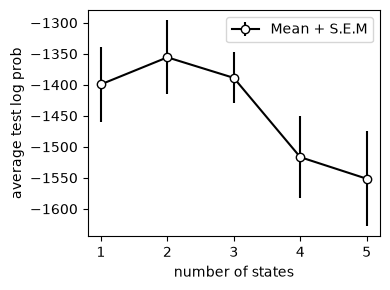

In [19]:
plt.figure(figsize = (4, 3))
plt.errorbar(num_states_range, avg_test_log_probs, yerr = np.array(std_test_log_probs)/np.sqrt(n_batches), mfc = 'w', color = 'k', marker = 'o')

# If you like, you can plot up each of the log_probs from the session.
#for k, test_log_probs in zip(num_states_range, all_test_log_probs):
#    plt.plot(k * np.ones(n_batches), test_log_probs, 'r.')

plt.legend(['Mean + S.E.M'])
plt.xlabel("number of states")
plt.ylabel("average test log prob")
plt.tight_layout()

In [20]:
key = jr.PRNGKey(0)
best_num_states = 2
number_of_states = best_num_states 
final_hmm = GaussianHMM(number_of_states, num_dimensions, transition_matrix_stickiness=10.)
params, param_props = final_hmm.initialize(key=key, method="kmeans", emissions=jnp.array(observations))
params, lps = final_hmm.fit_em(params, param_props, jnp.array(observations), num_iters=500)

<div><progress max="500" value="500"></progress> 100.00% [500/500 02:57&lt;00:00]</div>

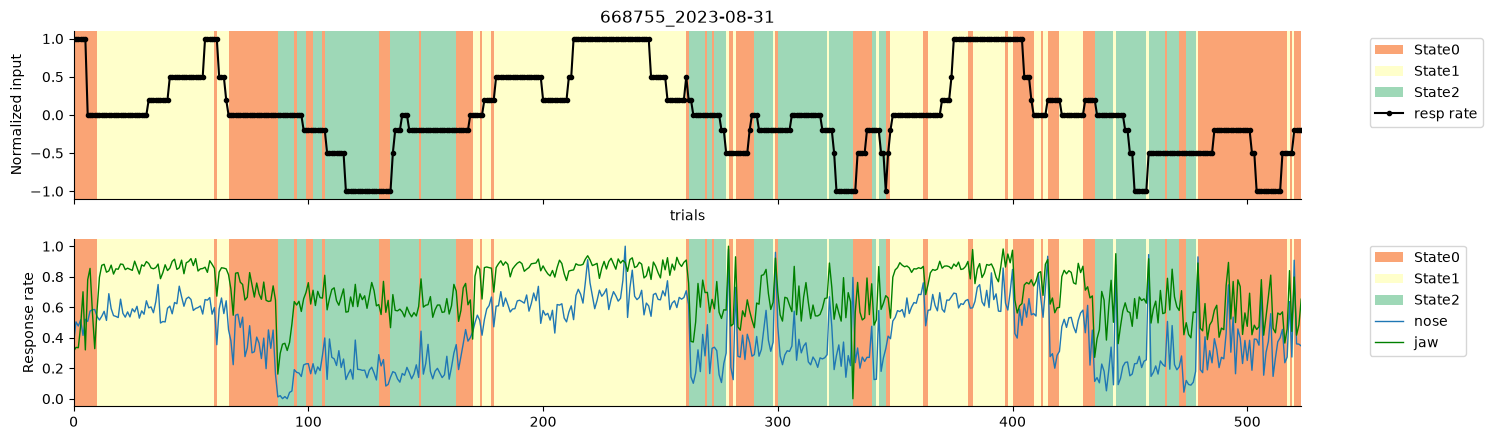

In [21]:
go_trials = np.arange(len(trials))

def minmax(x):
    # Function to normalize the data for easy visualization
    return (x - np.min(x))/(np.max(x) - np.min(x)) 


# Find the most likely discrete states given the learned model parameters
most_likely_states = final_hmm.most_likely_states(params, observations)

# Overlay the precision and recall curves on top of the inferred states
fig, ax = plt.subplots(2, 1, figsize=(15, 4.5), sharex=True)
cmap =sns.color_palette("Spectral", best_num_states)
bounds=np.arange(-0.5, best_num_states, 0.5)

# Define state boundaries 
states = most_likely_states
switch_trials = np.where(np.diff(states))[0]
switch_trials = np.concatenate(([0], switch_trials, [len(go_trials)-1]))

# Plot the states 
for j in range(2):
    for i, trial in enumerate(switch_trials[:-1]):
        for state_no in range(best_num_states):
            if states[trial+1] == state_no: 
                ax[j].axvspan(go_trials[trial], go_trials[switch_trials[i+1]], 
                        facecolor= cmap[state_no], alpha=0.8, label = 'State' + str(state_no))


# ax[0].plot(sound1_response_rate, color = 'k', label = 'sound1 resp rate', marker='.')
ax[0].plot(trials["response_modulation_index"], color = 'k', label = 'resp rate', marker = '.')
# ax[0].plot(sound1_hit_rate, color = 'r', label = 'aud1 resp rate', marker = '.')



# Overlay behavioral variables 
ax[1].plot(go_trials, minmax(behavior_df['nose']), color = 'tab:blue', label="nose", lw = 1)
ax[1].plot(go_trials, minmax(behavior_df['jaw']), color = 'green', label="jaw", lw = 1)



# Formatting 
ax[0].set_xlim(go_trials[0], go_trials[-1])
ax[0].set_title(f'{session_id}')
ax[0].set_ylabel("Normalized input")
ax[0].set_xlabel("trials")
handles, labels = ax[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[0].legend(by_label.values(), by_label.keys(), bbox_to_anchor = (1.05, 1), fontsize = 10)

ax[1].set_ylabel('Response rate')

handles, labels = ax[1].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[1].legend(by_label.values(), by_label.keys(), bbox_to_anchor = (1.05, 1), fontsize = 10)


for j in range(2): 
    ax[j].spines["top"].set_visible(False)
    ax[j].spines["right"].set_visible(False)


plt.tight_layout()

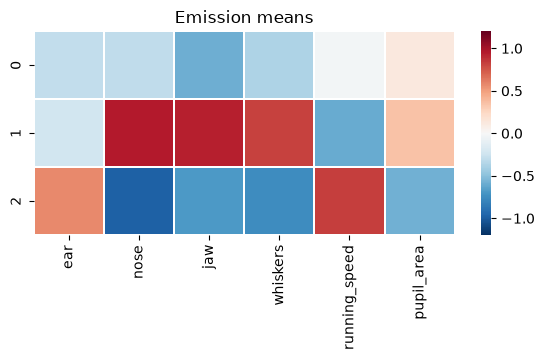

In [22]:
plt.figure(figsize = (5.8, 3.7))
sns.heatmap(params.emissions.means, xticklabels = behavior_df.keys(), yticklabels= np.arange(number_of_states), cmap = 'RdBu_r', linewidths=0.2, vmax = 1.2, vmin = -1.2)
plt.title('Emission means')
plt.tight_layout()